# linear regression from scratch by only using pandas and numpy
in this notebook i am building a full linear regression pipeline step by step in a very manual way, so it is easy to understand what is happening inside the model. i am not using sklearn for training here. i am doing feature engineering, feature scaling, regularized cost, gradients, gradient descent, and then visualizing how the optimization is moving. 

so here i am importing the necessary modules and loading the csv file first. after loading, i print only 3 rows and only important columns so i can quickly verify 3 things: file is read correctly, column names are exactly what i expect, and the values look numeric/usable for modeling. this is a small sanity check before doing any transformations.

In [40]:
import numpy as np
import pandas as pd

df = pd.read_csv("TSLA.csv")
print(df.head(3)[["Date","Close(t)","Volume","MA5","MA20","RSI","Close_forcast"]])

         Date  Close(t)    Volume      MA5      MA20        RSI  Close_forcast
0  2015-10-16    227.01   4334500  220.006  240.2085  41.229110         228.10
1  2015-10-19    228.10   2507900  222.510  238.4035  42.261535         213.03
2  2015-10-20    213.03  14900000  221.266  236.0080  33.499483         210.09


here i am doing the main feature preparation part. first i clean null rows, then i create a few extra features that can help linear regression capture short-term movement better than using raw close alone. `return_1d` tells daily relative movement, `ma_ratio` gives short trend vs longer trend, and `vol_log` compresses large volume spikes so they do not dominate gradients. i also keep `Close(t)` and `RSI` because they carry direct level + momentum information. after that i remove inf/nan again, do an 80/20 split in time order (not random), then convert everything into numpy arrays for faster math operations in gradient descent. finally i print train/val sizes and train feature means so i can quickly catch bad splits or strange values.

In [41]:
df = df.dropna().copy()
df["return_1d"] = (df["Close(t)"] / df["S_Close(t-1)"]) - 1
df["ma_ratio"] = df["MA5"] / df["MA20"]
df["vol_log"] = np.log1p(df["Volume"])
features = ["Close(t)", "return_1d", "ma_ratio", "vol_log", "RSI"]
target = "Close_forcast"
df_feat = df[features + [target]].replace([np.inf, -np.inf], np.nan).dropna()

m_total = len(df_feat)
split_idx = int(0.8 * m_total)
train = df_feat.iloc[:split_idx]
val = df_feat.iloc[split_idx:]

X_train = train[features].to_numpy()
y_train = train[target].to_numpy().reshape(-1, 1)
X_val = val[features].to_numpy()
y_val = val[target].to_numpy().reshape(-1, 1)

print(f"Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}")
print("Feature means (train):", X_train.mean(axis=0))

Train size: 972, Val size: 243
Feature means (train): [2.73595514e+02 3.84432290e-04 1.00007302e+00 1.55912942e+01
 5.04189987e+01]


in this step i scale every feature using train mean and train std. this is important because columns like volume can be very large while ratio/return columns are small; without scaling, gradient descent may zig-zag or converge very slowly. i apply the same train statistics to validation data so there is no data leakage. printing the first scaled row helps confirm shape and that transformed values look centered.

In [42]:
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)
X_train_norm = (X_train - mu) / sigma
X_val_norm = (X_val - mu) / sigma

print("First row after scaling:", X_train_norm[0])

First row after scaling: [-0.82420649  0.87654801 -1.56190826 -0.58067625 -0.744177  ]


this is the regularized cost function in explicit w and b form. model prediction is `X dot w + b`. then i compute squared error over all examples and average it with `1/(2m)`. after that i add l2 penalty on `w` only (not on `b`) so weights do not explode and model stays more stable/generalizable. this same function is used for both train and validation reporting, so metric is consistent everywhere.

In [43]:
def compute_cost(X, y, w, b, lambda_):
    m = X.shape[0]
    f_wb = np.dot(X, w) + b
    error = f_wb - y
    reg = (lambda_ / (2 * m)) * np.sum(w ** 2)
    total_cost = (1 / (2 * m)) * np.sum(error ** 2) + reg
    return total_cost

here i define gradient logic and full batch gradient descent using explicit `w` and `b`, similar to the course style. `compute_gradient` calculates `dj_dw` and `dj_db` from current predictions, and includes regularization term in `dj_dw`. `gradient_descent` then repeats updates for fixed iterations using learning rate alpha. i also store cost history, w1 history, and sampled iteration values every 100 steps so i can plot optimization behavior later. after training, i print final shapes/values and compare train vs validation cost to check if model is fitting reasonably.

In [44]:
def compute_gradient(X, y, w, b, lambda_):
    m = X.shape[0]
    f_wb = np.dot(X, w) + b
    error = f_wb - y
    dj_dw = (1 / m) * np.dot(X.T, error) + (lambda_ / m) * w
    dj_db = (1 / m) * np.sum(error)
    return dj_dw, dj_db

def gradient_descent(X, y, w_in, b_in, alpha, num_iters, lambda_):
    w = w_in.copy()
    b = b_in
    J_history = []
    w1_history = []
    iter_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b, lambda_)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i % 100 == 0:
            J_history.append(compute_cost(X, y, w, b, lambda_))
            w1_history.append(w[0, 0])
            iter_history.append(i)
    return w, b, J_history, w1_history, iter_history

alpha = 0.01
num_iters = 2000
lambda_ = 0.1
initial_w = np.zeros((X_train_norm.shape[1], 1))
initial_b = 0.0

w, b, J_hist, w1_hist, iter_hist = gradient_descent(
    X_train_norm, y_train, initial_w, initial_b, alpha, num_iters, lambda_
)

train_cost = compute_cost(X_train_norm, y_train, w, b, lambda_)
val_cost = compute_cost(X_val_norm, y_val, w, b, lambda_)

print("w shape:", w.shape)
print("b:", b)
print("Train cost:", train_cost)
print("Val cost:", val_cost)

w shape: (5, 1)
b: 273.58376492220515
Train cost: 32.807782738975945
Val cost: 880.9907269213313


this cell is a quick consistency check. i recompute validation cost again using the final trained `w` and `b` with the exact same cost function. reason is simple: while experimenting with alpha/lambda/features, this gives a fast checkpoint number without scrolling back, and confirms that latest model state is what i think it is.

In [45]:
val_cost = compute_cost(X_val_norm, y_val, w, b, lambda_)
print("Validation cost (recomputed):", val_cost)

Validation cost (recomputed): 880.9907269213313


now i am plotting two useful views of optimization. plot 1 shows `iterations vs cost J`, which tells whether training is going down smoothly and converging. plot 2 shows `w1 vs cost J`, which gives intuition for how cost changes as one weight moves during training steps. together these plots help debug learning rate issues (too high, too low) and confirm gradient descent is actually optimizing the objective instead of bouncing around.

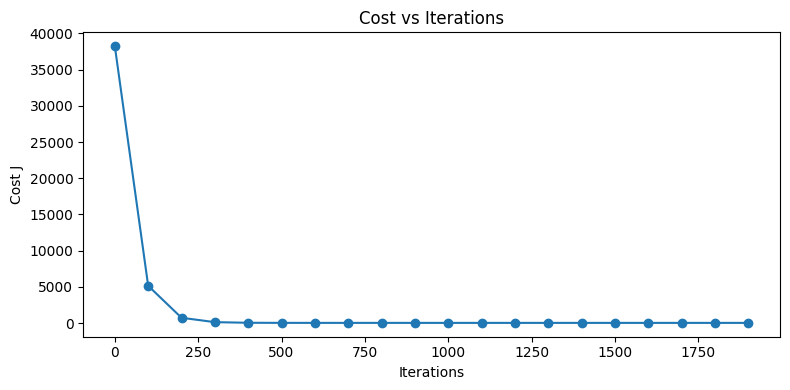

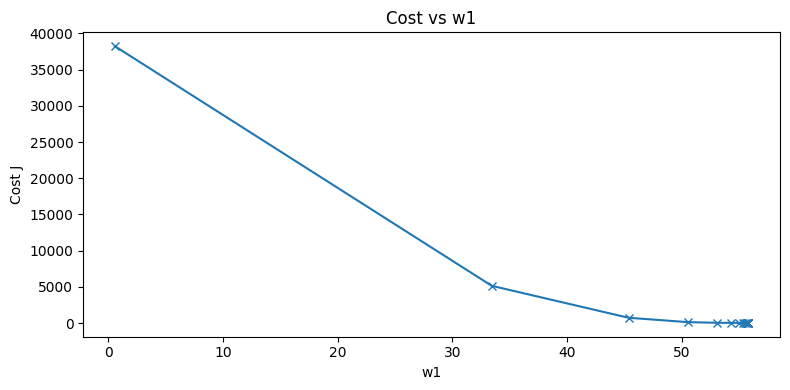

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(iter_hist, J_hist, marker='o')
plt.xlabel('Iterations')
plt.ylabel('Cost J')
plt.title('Cost vs Iterations')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(w1_hist, J_hist, marker='x')
plt.xlabel('w1')
plt.ylabel('Cost J')
plt.title('Cost vs w1')
plt.tight_layout()
plt.show()

i am printing the three main mett

In [47]:
val_pred = np.dot(X_val_norm, w) + b

mse = np.mean((val_pred - y_val) ** 2)
rmse = np.sqrt(mse)
ss_res = np.sum((y_val - val_pred) ** 2)
ss_tot = np.sum((y_val - np.mean(y_val)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 score:", r2)

MSE: 1760.698475359964
RMSE: 41.96067772760545
R2 score: 0.9884383081799657
